In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import gudhi as gd
from gudhi.representations import Silhouette

In [ ]:
X, y = torch.load("./ORBIT/dataset/data.pt", weights_only=True)
print(X.shape, y.shape)

ind0 = (y == 0)
ind1 = (y == 1)
ind2 = (y == 2)
ind3 = (y == 3)
ind4 = (y == 4)

# Point cloud data

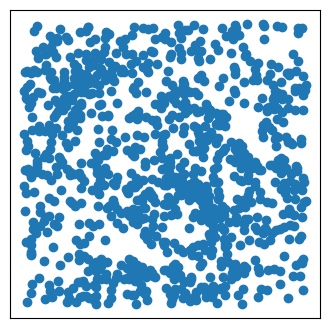

In [ ]:
# r = 2.5
i=100
plt.figure(figsize=(4,4))
plt.scatter(X[ind0][i][:, 0], X[ind0][i][:, 1])
plt.xticks([])
plt.yticks([])
plt.show();

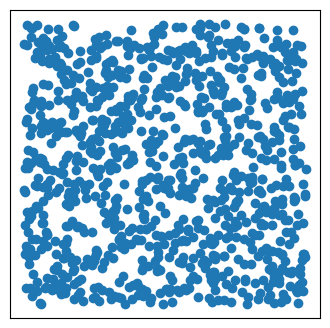

In [ ]:
# r = 3.5
i=130
plt.figure(figsize=(4,4))
plt.scatter(X[ind1][i][:, 0], X[ind1][i][:, 1])
plt.xticks([])
plt.yticks([])
plt.show();

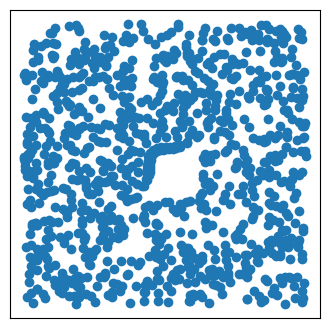

In [ ]:
# r = 4.0
i=0
plt.figure(figsize=(4,4))
plt.scatter(X[ind2][i][:, 0], X[ind2][i][:, 1])
plt.xticks([])
plt.yticks([])
plt.show();

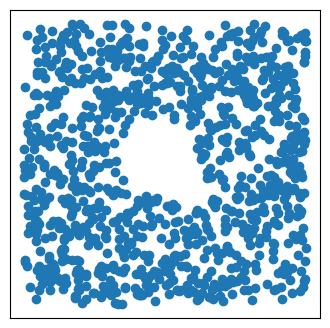

In [ ]:
# r = 4.1
i=0
plt.figure(figsize=(4,4))
plt.scatter(X[ind3][i][:, 0], X[ind3][i][:, 1])
plt.xticks([])
plt.yticks([])
plt.show();

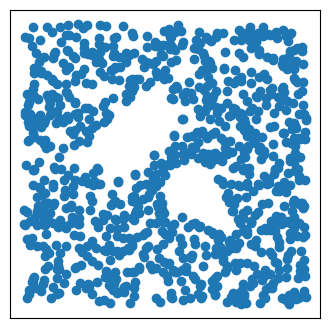

In [ ]:
# r = 4.3
i=1
plt.figure(figsize=(4,4))
plt.scatter(X[ind4][i][:, 0], X[ind4][i][:, 1])
plt.xticks([])
plt.yticks([])
plt.show();

# Sillhouette

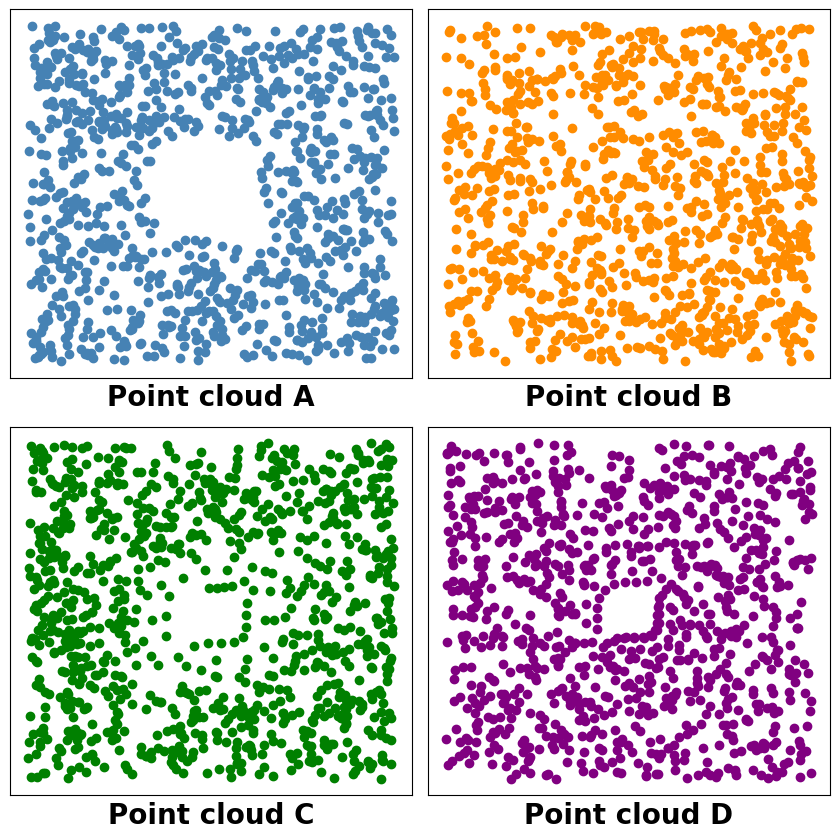

In [ ]:
# point clouds
pc1 = X[ind3][i]
# pc1 = X[ind4][i]
pc2 = X[ind1][i]
pc3 = X[ind2][i+21]
pc4 = X[ind2][i]
# pc4 = X[ind2][i+78]


# plot point cloud
c1 = "steelblue"
c2 = "darkorange"
c3 = "green"
c4 = "purple"

fig, (ax) = plt.subplots(2,2, figsize=(8.5,8.5))
# fig, (ax1, ax2) = plt.subplots(1,2, figsize=(7, 4))
ax[0,0].scatter(pc1[:,0], pc1[:,1], c=c1)
ax[0,0].set_xticks([])
ax[0,0].set_yticks([])
ax[0,0].set_xlabel("Point cloud A", fontsize=20, fontweight="bold")

ax[0,1].scatter(pc2[:,0], pc2[:,1], c=c2)
ax[0,1].set_xticks([])
ax[0,1].set_yticks([])
ax[0,1].set_xlabel("Point cloud B", fontsize=20, fontweight="bold")

ax[1,0].scatter(pc3[:,0], pc3[:,1], c=c3)
ax[1,0].set_xticks([])
ax[1,0].set_yticks([])
ax[1,0].set_xlabel("Point cloud C", fontsize=20, fontweight="bold")

ax[1,1].scatter(pc4[:,0], pc4[:,1], c=c4)
ax[1,1].set_xticks([])
ax[1,1].set_yticks([])
ax[1,1].set_xlabel("Point cloud D", fontsize=20, fontweight="bold")



plt.tight_layout()
plt.show();

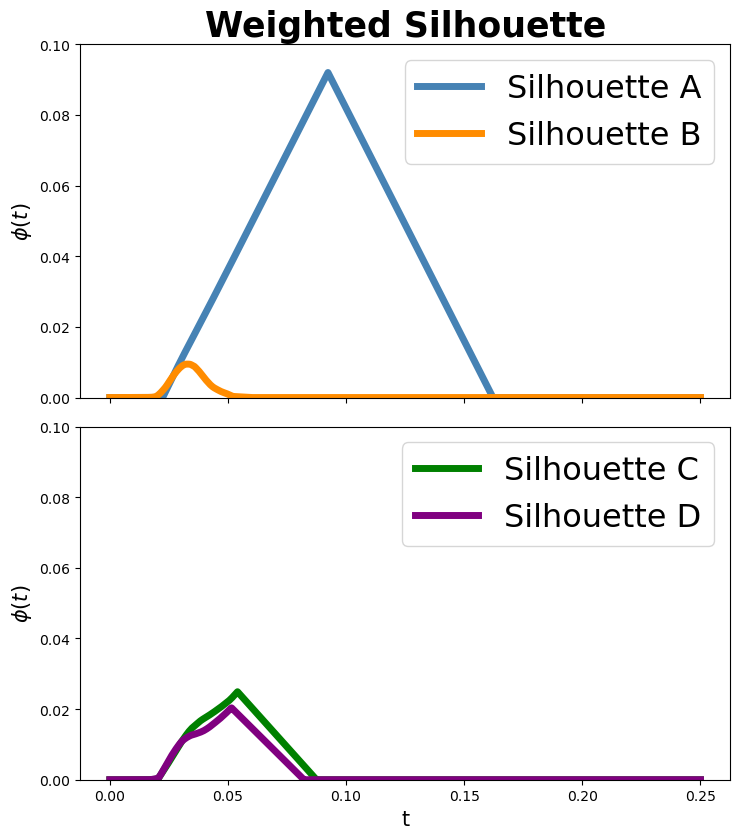

In [ ]:
# Step 2: Build the Alpha Complex
alpha1 = gd.AlphaComplex(points=pc1)
st1 = alpha1.create_simplex_tree()

alpha2 = gd.AlphaComplex(points=pc2)
st2 = alpha2.create_simplex_tree()

alpha3 = gd.AlphaComplex(points=pc3)
st3 = alpha3.create_simplex_tree()

alpha4 = gd.AlphaComplex(points=pc4)
st4 = alpha4.create_simplex_tree()


# Step 3: Compute persistence diagram in H1
st1.compute_persistence()
diag1 = st1.persistence_intervals_in_dimension(1)

st2.compute_persistence()
diag2 = st2.persistence_intervals_in_dimension(1)

st3.compute_persistence()
diag3 = st3.persistence_intervals_in_dimension(1)

st4.compute_persistence()
diag4 = st4.persistence_intervals_in_dimension(1)

# use radius rather than radius^2
diag1 = np.sqrt(diag1)
diag2 = np.sqrt(diag2)
diag3 = np.sqrt(diag3)
diag4 = np.sqrt(diag4)

# Optional: Filter out infinite bars
# finite_bars = diag[np.isfinite(diag[:, 1])]


# Step 4: Define weight function (e.g., birth-death persistence)
res = 1000

def power_weight(point, r=3):
    birth, death = point
    return np.abs(death - birth)**r

t_max1 = 0.25
silhouette = Silhouette(weight=power_weight, resolution=res, sample_range=[0, t_max1], keep_endpoints=True)
y1 = silhouette.fit_transform([diag1])[0]
y2 = silhouette.fit_transform([diag2])[0]

t_max2 = 0.25
silhouette = Silhouette(weight=power_weight, resolution=res, sample_range=[0, t_max2], keep_endpoints=True)
y3 = silhouette.fit_transform([diag3])[0]
y4 = silhouette.fit_transform([diag4])[0]


# Step 6: Plot the silhouette
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(7.5, 8.5), sharex=True)
t_vals1 = np.linspace(0, t_max1, res)
t_vals2 = np.linspace(0, t_max2, res)

ax1.plot(t_vals1, y1, lw=5, c=c1, label="Silhouette A")
ax1.plot(t_vals1, y2, lw=5, c=c2, label="Silhouette B")
ax1.set_title("Weighted Silhouette", fontsize=25, fontweight="bold")
ax1.set_ylim([0,0.1])
ax1.set_ylabel(r"$\phi(t)$", fontsize=15)
ax1.legend(loc="upper right", prop={"size":23})

ax2.plot(t_vals2, y3, lw=5, c=c3, label="Silhouette C")
ax2.plot(t_vals2, y4, lw=5, c=c4, label="Silhouette D")
ax2.set_ylim([0,0.1])
ax2.set_xlabel("t", fontsize=15)
ax2.set_ylabel(r"$\phi(t)$", fontsize=15)
ax2.legend(prop={"size":23})

plt.tight_layout()
plt.show();

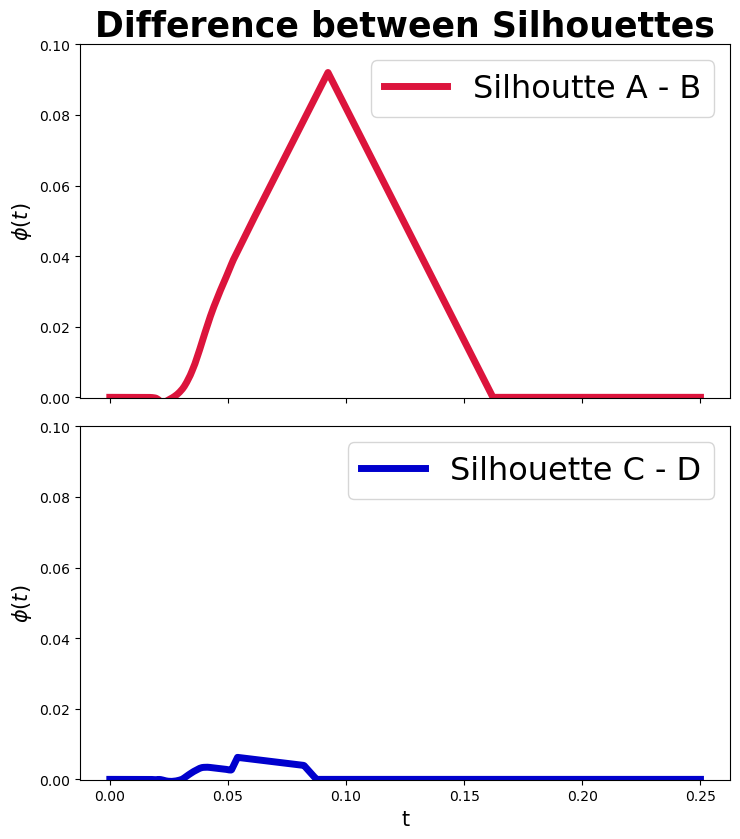

In [ ]:
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(7.5, 8.5), sharex=True)

ax1.plot(t_vals1, y1 - y2, lw=5, c="crimson", label="Silhoutte A - B")
ax1.set_title("Difference between Silhouettes", fontsize=25, fontweight="bold")
ax1.set_ylim([-1e-4, 0.1])
ax1.set_ylabel(r"$\phi(t)$", fontsize=15)
ax1.legend(loc="upper right", prop={"size":23})

ax2.plot(t_vals2, y3 - y4, lw=5, c="mediumblue", label="Silhouette C - D")
ax2.set_ylim([-1e-4, 0.1])
ax2.set_xlabel("t", fontsize=15)
ax2.set_ylabel(r"$\phi(t)$", fontsize=15)
ax2.legend(loc="upper right", prop={"size":23})

plt.tight_layout()
plt.show();